
# Step 04 — PCA, neighbours, UMAP and Leiden clustering

**Purpose.** Reduce the scaled HVG matrix to a small number of components, build a
neighbour graph, embed it for visualisation, and partition it into clusters that
Step 05 will annotate.

**Baseline:** `n_pcs = 20`, `n_neighbors = 15`, Leiden `resolution = 0.6`.

**On integration.** The paper integrated across samples (Seurat, dims = 30). We do
**not** integrate by default. In this design each timepoint is its own pair of 10x
runs, so `sample` and `condition` are confounded: correcting on `sample` can
delete the injury response along with the batch effect. The decision is made from
the diagnostics below and written down either way.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
import pandas as pd
adata = io_utils.load_checkpoint("preprocessed")

Loaded 'preprocessed': 15893 cells x 2000 genes



## 1. PCA and how many components to keep

PCA: 50 components, 27.6% of variance retained.
Elbow heuristic suggests ~50 PCs; baseline in use is 20 (config.N_PCS_NEIGHBORS).
Saved figure_s2_pca_variance -> figures\figure_02_umap/ (png, pdf)


,PC,variance_ratio,cumulative_variance_ratio
0,1,0.0441,0.0441
1,2,0.0346,0.0786
2,3,0.0288,0.1074
3,4,0.0182,0.1257
4,5,0.0131,0.1388
5,6,0.0124,0.1512
6,7,0.0116,0.1628
7,8,0.0095,0.1722
8,9,0.0063,0.1785
9,10,0.0054,0.1839


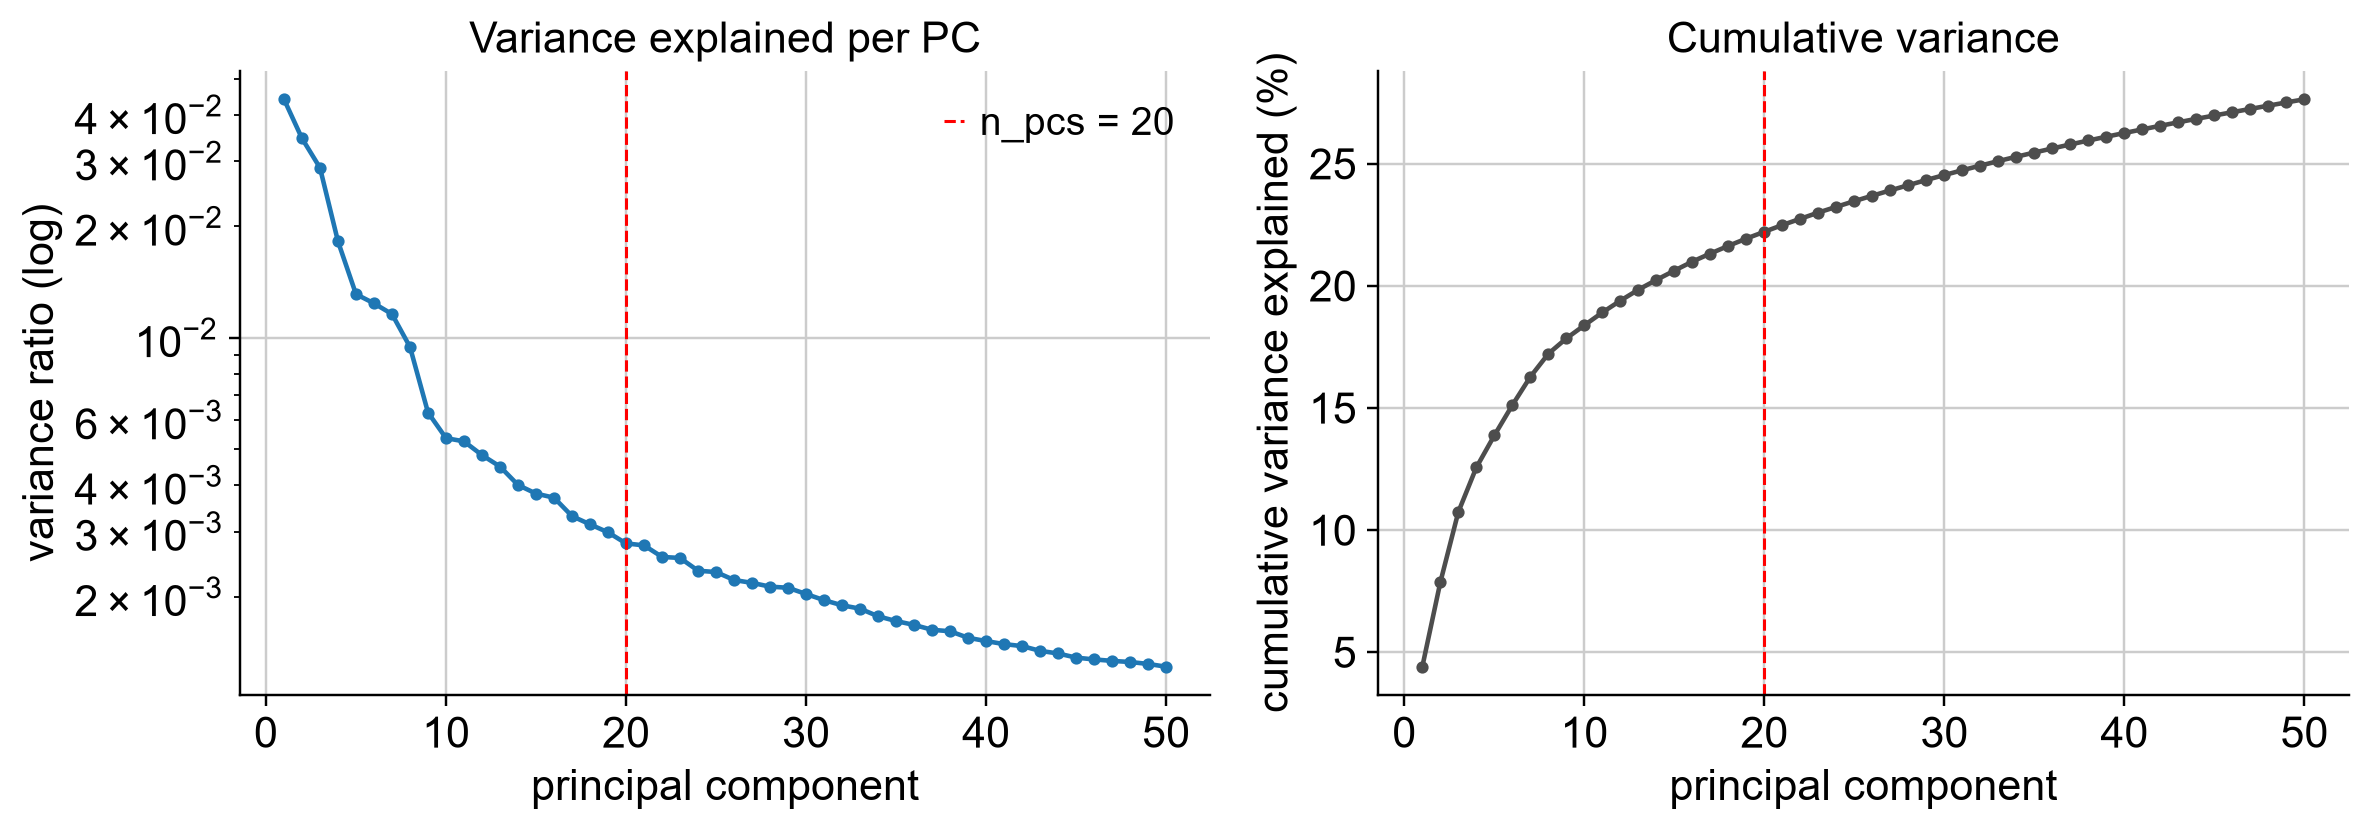

In [3]:
adata = clustering.run_pca(adata)
variance_table = clustering.pca_variance_table(adata)
suggested = clustering.suggest_n_pcs(adata)
fig = plotting.figure_pca_variance(variance_table, n_pcs_used=cfg.N_PCS_NEIGHBORS)
display(variance_table.head(30).round(4))


### Interpretation

The elbow heuristic is advisory. Keep `n_pcs = 20` unless the plot clearly
disagrees — and if you change it, edit `cfg.N_PCS_NEIGHBORS`, record it in
`cfg.PARAM_OVERRIDES`, and say so in the Methods section. Too few PCs merges
genuinely distinct cell types; too many mostly adds noise and slows the graph
build without changing the biology much.


## 2. Batch diagnostics — decide about integration on evidence

For each of the first 20 PCs, how much variance is explained by `condition`
(biology + confounded run) versus `replicate` (technical only)? Replicate is the
cleaner read on batch: replicates within a condition differ *only* technically.

In [4]:
diag = clustering.batch_diagnostics(adata)
for note in clustering.interpret_batch_diagnostics(diag):
    print(f"- {note}")

io_utils.save_table(
    diag.groupby("factor")["variance_explained"].mean().round(4).reset_index(),
    "batch_diagnostics.csv",
)

Mean fraction of PC variance explained (first 20 PCs):
factor
condition    0.0201
replicate    0.0023
sample       0.0244
- condition explains 2.0% of PC variance on average; replicate explains 0.2%.
- Condition structure dominates, which is the expected design here. Integrating on 'sample' would remove the injury effect along with the batch effect, so the uncorrected embedding is kept as the primary result.
- Caveat: condition and 10x run are fully confounded in this design (each timepoint has its own pair of runs), so no method can fully separate true injury response from run-to-run technical variation. State this as a limitation rather than claiming the batch effect was removed.
Wrote tables\batch_diagnostics.csv  (3 rows)


WindowsPath('D:/retina/project1_zebrafish_retina/tables/batch_diagnostics.csv')

In [5]:
# Integration is OFF unless config says otherwise. Flip cfg.USE_INTEGRATION only
# with a written justification, and keep the uncorrected UMAP for comparison.
use_rep = None
if cfg.USE_INTEGRATION:
    use_rep = clustering.run_integration(adata)
    print(f"Integration applied; downstream graph uses representation '{use_rep}'.")
else:
    print("No integration applied. Rationale recorded in the Methods section.")

No integration applied. Rationale recorded in the Methods section.



## 3. Neighbour graph, UMAP and Leiden

In [6]:
adata = clustering.run_neighbors_umap(adata, use_rep=use_rep)
adata = clustering.run_leiden(adata)
print(adata.obs[cfg.LEIDEN_KEY].value_counts().sort_index().to_string())

D:\retina\project1_zebrafish_retina\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Neighbour graph: k=15, n_pcs=20; UMAP computed.
Leiden resolution 0.6: 20 clusters -> obs['leiden_res_0.6']
leiden_res_0.6
0     1881
1       15
2     2433
3     1274
4     1062
5      202
6     1471
7      336
8      712
9     1574
10    1040
11     760
12      87
13    1624
14     350
15      97
16     661
17     134
18      51
19     129



## Figure 2 — global cell atlas

Saved figure_02_umap_atlas -> figures\figure_02_umap/ (png, pdf)
Saved figure_02_umap_split_by_condition -> figures\figure_02_umap/ (png, pdf)


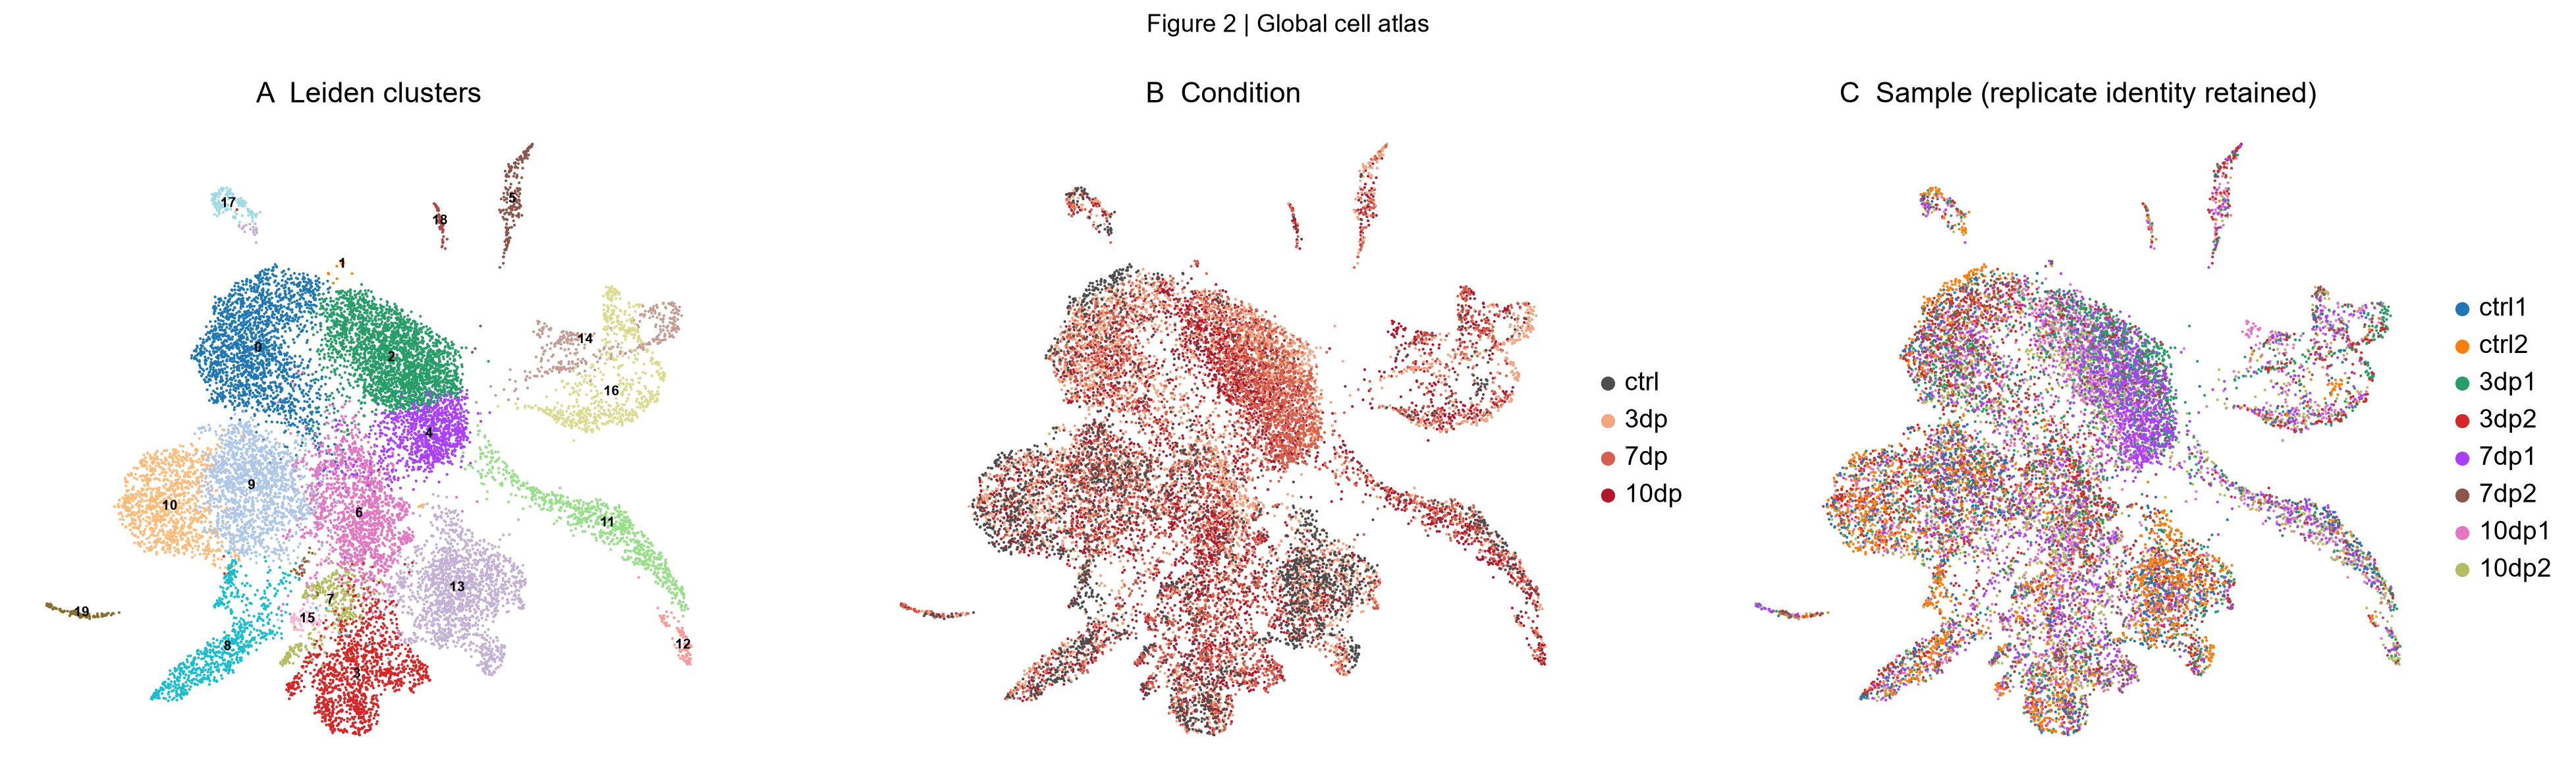

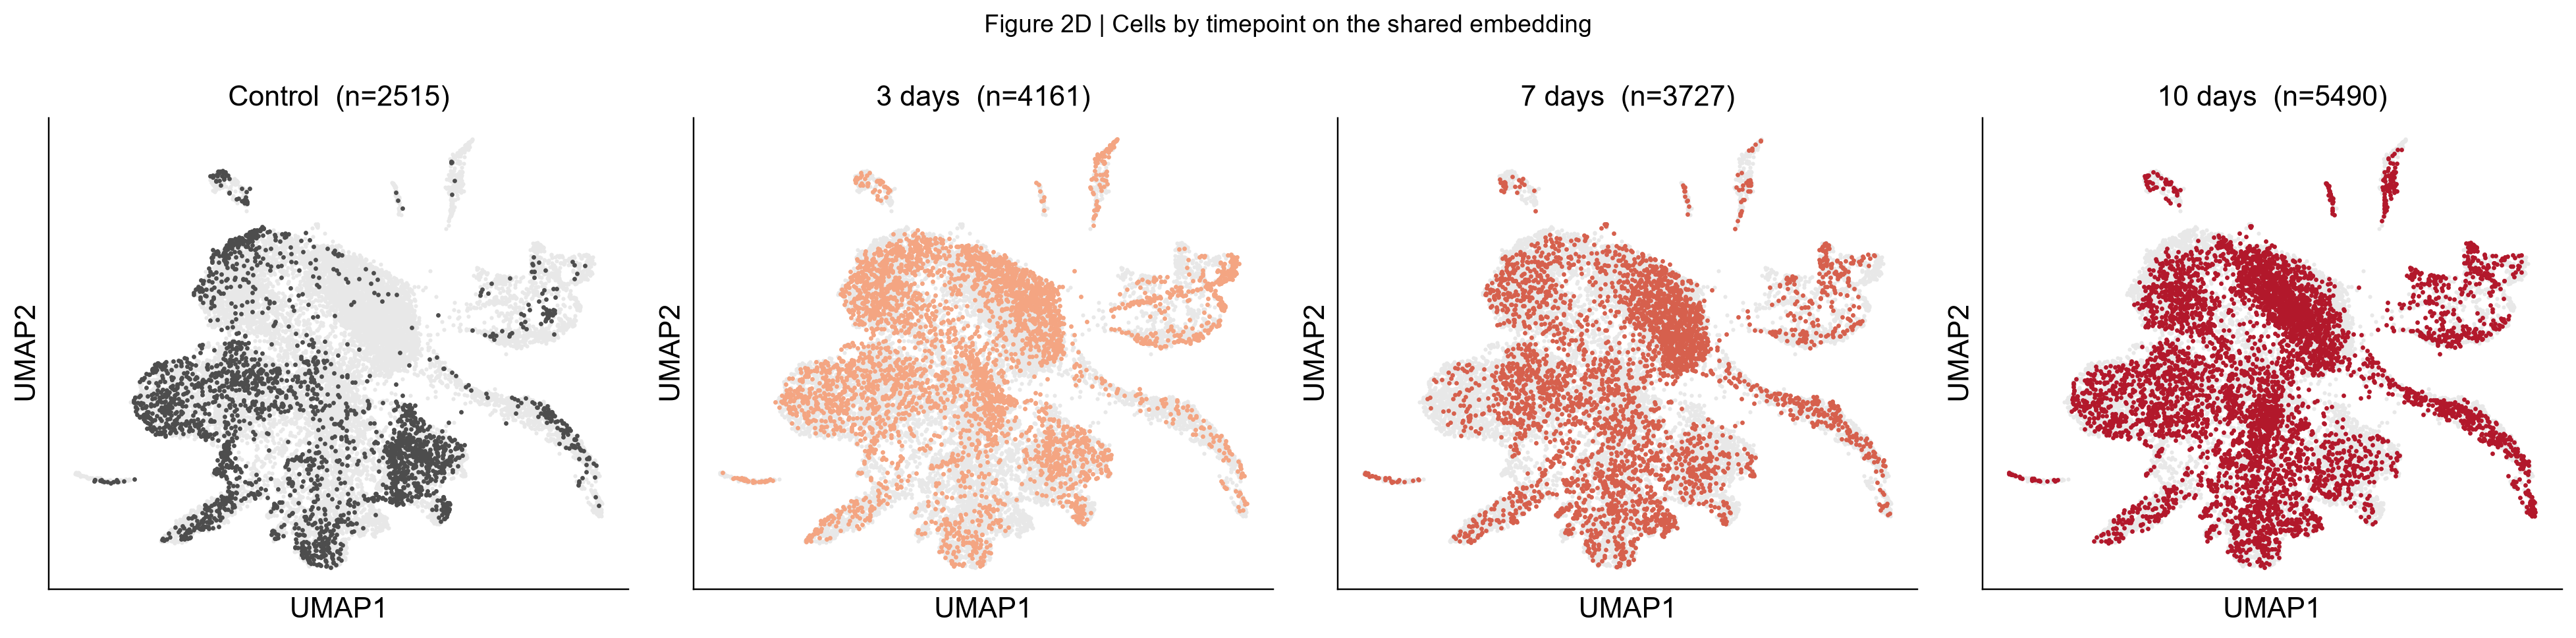

In [7]:
fig = plotting.figure_02_umap(adata)
fig = plotting.figure_02_split_by_condition(adata)


### Interpretation — is this clustering plausible?

Three things to look at, in this order:

1. **Does the UMAP separate into a few large, well-separated islands?** Retina is
   dominated numerically by photoreceptors, so a very large rod territory with
   smaller satellites is the expected shape, not a warning sign.
2. **Do clusters mix across samples?** Panel C should show most clusters
   containing cells from several samples. A cluster made almost entirely of one
   run is a technical-artefact candidate — flagged automatically below.
3. **Does condition structure look biological?** Injured cells shifting *within* a
   cell-type island (a stress/activation gradient) is biology. Whole clusters that
   exist only in one timepoint need a marker-based explanation before they can be
   called a new cell state.

In [8]:
flagged = clustering.flag_single_sample_clusters(adata)
display(flagged)

composition = clustering.cluster_composition(adata)
io_utils.save_table(composition, "cluster_composition.csv")

No cluster is >=90.0% derived from a single sample.


,leiden_res_0.6,condition,sample,n_cells,pct_of_cluster


Wrote tables\cluster_composition.csv  (155 rows)


WindowsPath('D:/retina/project1_zebrafish_retina/tables/cluster_composition.csv')


## 4. Resolution stability

Evidence that resolution 0.6 is a reasonable operating point rather than a lucky
pick. The reported clustering stays at 0.6.

In [9]:
sweep = clustering.resolution_sweep(adata)
io_utils.save_table(sweep, "leiden_resolution_sweep.csv")
display(sweep)

Leiden resolution 0.2: 12 clusters -> obs['leiden_res_0.2']
Leiden resolution 0.4: 13 clusters -> obs['leiden_res_0.4']
Leiden resolution 0.8: 24 clusters -> obs['leiden_res_0.8']
Leiden resolution 1.0: 26 clusters -> obs['leiden_res_1.0']
Wrote tables\leiden_resolution_sweep.csv  (5 rows)


,resolution,n_clusters,smallest_cluster,largest_cluster,n_clusters_under_50_cells
0,0.2,12,51,3470,0
1,0.4,13,51,3494,0
2,0.6,20,15,2433,1
3,0.8,24,15,2476,1
4,1.0,26,51,2423,0


In [10]:
io_utils.save_checkpoint(adata, "clustered")

Saved checkpoint 'clustered' -> results\04_clustered.h5ad (179.6 MB)


WindowsPath('D:/retina/project1_zebrafish_retina/results/04_clustered.h5ad')


### What to check before continuing

- [ ] Cluster count is in a workable range (roughly 10–25 for adult retina at res 0.6).
- [ ] No cluster is >90% one sample, or those that are have been investigated.
- [ ] The integrate / do-not-integrate decision is written down with its reason.
- [ ] Figure 2 saved as PNG and PDF.
- [ ] `results/04_clustered.h5ad` exists.